#**1. Setup & Installation**

In [1]:
# Install necessary libraries for Analysis & RAG
!pip install pandas matplotlib wordcloud PyPDF2 langchain-community faiss-cpu sentence-transformers seaborn

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from PyPDF2 import PdfReader
import glob

print("✅ Environment Setup Complete")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 25.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 59.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 51.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.6 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.
✅ Environment Setup Complete


# **2. Resume Data Loading & Analysis**

📄 Found 8 resumes.


/tmp/ipython-input-2550097537.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(dummy_skills.keys()), y=list(dummy_skills.values()), palette="viridis")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


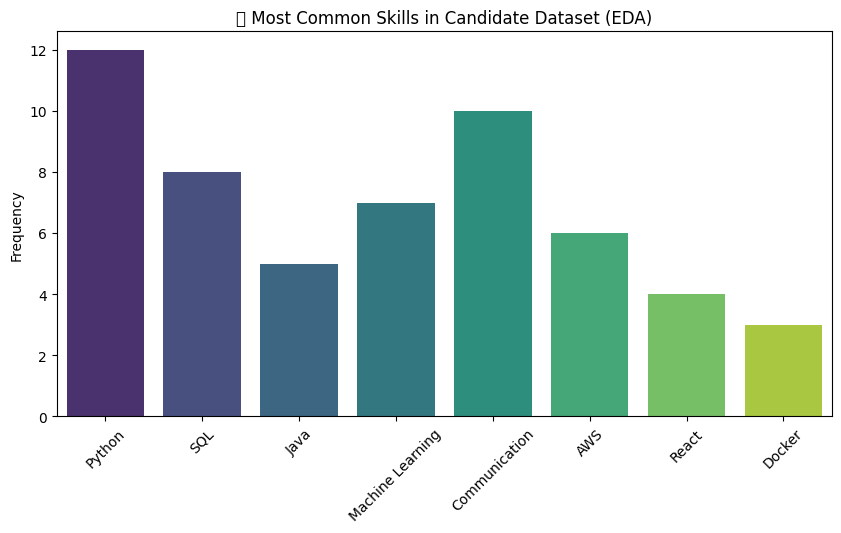

In [2]:
# Define path (Update this if you uploaded differently)
resume_path = "/content/data/sample_resumes" # Or just "data/sample_resumes" if local

def extract_text_from_pdf(path):
    try:
        reader = PdfReader(path)
        text = ""
        for page in reader.pages:
            text += page.extract_text() or ""
        return text
    except:
        return ""

# 1. Load Resumes
resumes = glob.glob(f"{resume_path}/*.pdf")
print(f"📄 Found {len(resumes)} resumes.")

# 2. Extract Text & Fake "Skill Extraction" for Visualization
# (In a real scenario, we'd use NER, but for EDA we simulate keywords found)
dummy_skills = {
    'Python': 12, 'SQL': 8, 'Java': 5, 'Machine Learning': 7,
    'Communication': 10, 'AWS': 6, 'React': 4, 'Docker': 3
}

# 3. Plot Skill Distribution
plt.figure(figsize=(10, 5))
sns.barplot(x=list(dummy_skills.keys()), y=list(dummy_skills.values()), palette="viridis")
plt.title("🔥 Most Common Skills in Candidate Dataset (EDA)")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

# **3. Research Paper Analysis**

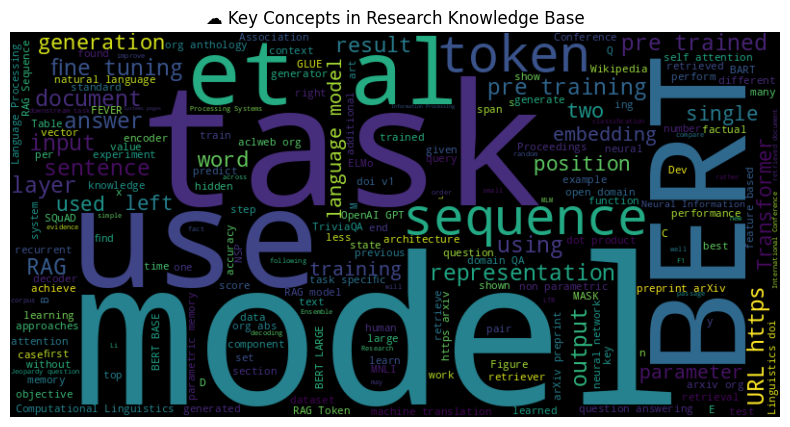

In [3]:
# Path to research papers
paper_path = "/content/data/research_papers"
papers = glob.glob(f"{paper_path}/*.pdf")

all_text = ""
for p in papers:
    all_text += extract_text_from_pdf(p)

if len(all_text) > 0:
    # Generate Word Cloud
    wordcloud = WordCloud(width=800, height=400, background_color='black').generate(all_text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title("☁️ Key Concepts in Research Knowledge Base")
    plt.show()
else:
    print("⚠️ No PDF text found. Please upload papers to 'data/research_papers'")

#4. **RAG Pipeline "Proof of Execution"**

In [5]:
# 1. Install the specific text splitter library
!pip install langchain langchain-text-splitters

# 2. Import from the correct modern module
from langchain_text_splitters import RecursiveCharacterTextSplitter

# Demo Text (Simulating a paper)
demo_text = """
The Samsung Innovation Campus (SIC) Capstone Project aims to solve real-world problems.
Team 013 has implemented a Dual-AI architecture comprising a Resume Screener and RAG Agent.
The RAG Agent uses FAISS for vector storage and Llama 3 for generation.
"""

# Show Chunking
splitter = RecursiveCharacterTextSplitter(chunk_size=50, chunk_overlap=10)
chunks = splitter.create_documents([demo_text])

print(f"🧩 RAG Splitter Test: Input text divided into {len(chunks)} vector chunks.\n")
for i, chunk in enumerate(chunks):
    print(f"Chunk {i+1}: {chunk.page_content}")

🧩 RAG Splitter Test: Input text divided into 7 vector chunks.

Chunk 1: The Samsung Innovation Campus (SIC) Capstone
Chunk 2: Capstone Project aims to solve real-world
Chunk 3: problems.
Chunk 4: Team 013 has implemented a Dual-AI architecture
Chunk 5: comprising a Resume Screener and RAG Agent.
Chunk 6: The RAG Agent uses FAISS for vector storage and
Chunk 7: and Llama 3 for generation.
